<a href="https://colab.research.google.com/github/Matheusbcy/22-machine-learning-projects/blob/main/Intermediario/Processamento%20de%20Imagem/Fruits_360.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Instalação e importação das bibliotecas**


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, GlobalAveragePooling2D, Rescaling
from tensorflow.keras.utils import set_random_seed
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(tf.__version__)

2.19.0


In [ ]:
import sklearn
from sklearn.model_selection import train_test_split
print(sklearn.__version__)

1.6.1


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
print(matplotlib.__version__)

3.10.0


In [ ]:
tf.config.experimental.enable_op_determinism()
set_random_seed(42)

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
path = '/content/gdrive/MyDrive/22 Project ML - Data Science/Intermediario/Fruits/images'

# **Carregamento e pré-processamento**

In [ ]:
img_height = 224
img_width = 224
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split = 0.2,
    subset = "training",
    image_size = (img_height, img_width),
    batch_size = batch_size,
    seed = 123
)

class_names = train_ds.class_names
print("Classes:", class_names)

test_ds = tf.keras.utils.image_dataset_from_directory(
    path,
    validation_split = 0.2,
    subset = "validation",
    seed = 123,
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 360 files belonging to 9 classes.
Using 288 files for training.
Classes: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
Found 360 files belonging to 9 classes.
Using 72 files for validation.


In [ ]:
print("Classes:", train_ds.class_names)
print("Lotes de treino:", len(train_ds))
print("Lotes de teste:", len(test_ds))

Classes: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
Lotes de treino: 9
Lotes de teste: 3


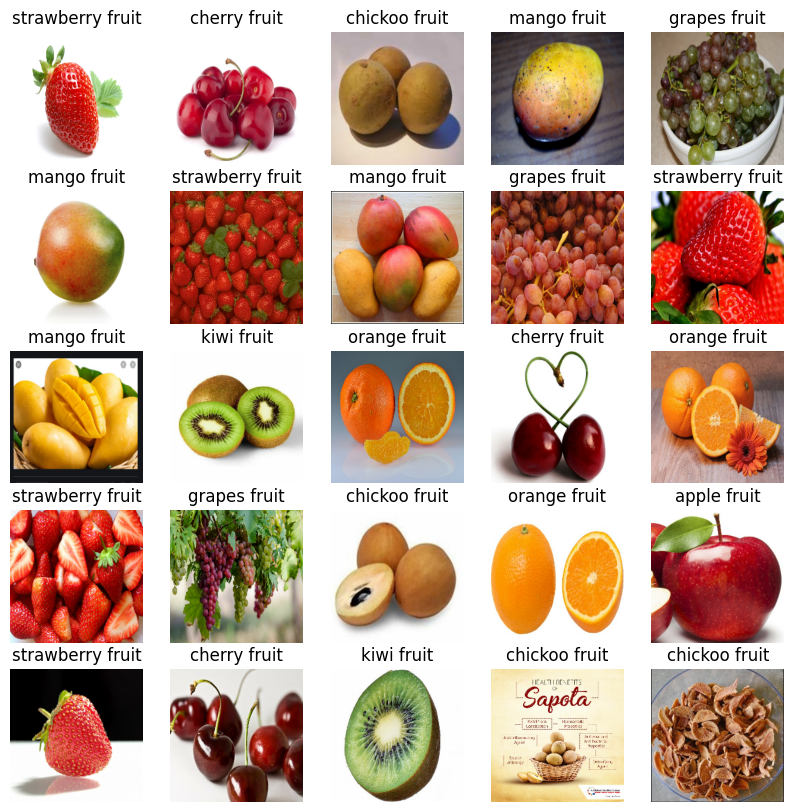

In [ ]:
plt.figure(figsize = (10, 10))

for images, labels in train_ds.take(1):
  for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

# Normalizar para Treino

In [ ]:
# Descobrir o shape da imagem que foi carregada pelo tensorflow
for images, labels in train_ds.take(1):
    print("Shape das imagens:", images.shape)

Shape das imagens: (32, 224, 224, 3)


In [ ]:
num_classes = len(class_names)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Lambda(preprocess_input),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(num_classes, activation="softmax")
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=40,
    callbacks=[callback]
)

Epoch 1/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.0876 - loss: 2.7886 - val_accuracy: 0.1944 - val_loss: 2.3120
Epoch 2/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1126 - loss: 2.5921 - val_accuracy: 0.3056 - val_loss: 2.0455
Epoch 3/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 843ms/step - accuracy: 0.2181 - loss: 2.2151 - val_accuracy: 0.4444 - val_loss: 1.8344
Epoch 4/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 812ms/step - accuracy: 0.3661 - loss: 1.8444 - val_accuracy: 0.5139 - val_loss: 1.6597
Epoch 5/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3672 - loss: 1.7874 - val_accuracy: 0.6528 - val_loss: 1.4980
Epoch 6/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 987ms/step - accuracy: 0.4588 - loss: 1.6017 - val_accuracy: 0.6667 - val_loss: 1.3641
Epoch 7/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 792ms/step - accuracy: 0.5714 - loss: 1.4046 - val_accuracy: 0.7083 - val_loss: 1.2428
Epoch 8/40
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 936ms/step - accuracy: 0.5769 - loss: 1.2949 - val_accuracy: 0.7639 - val_loss: 1.14

In [ ]:
model.save("modelo_frutas_mobilenet.h5")

# Avaliação do Modelo

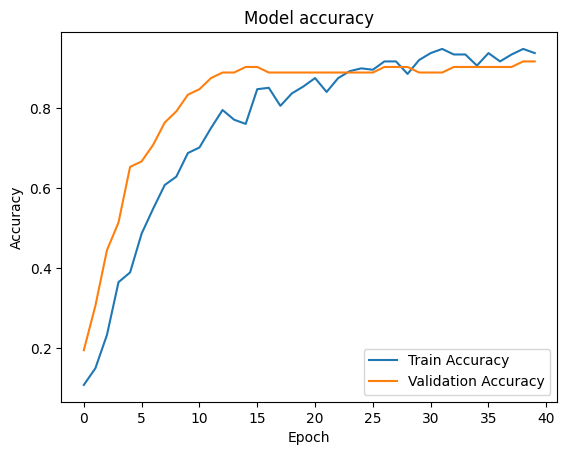

In [ ]:
plt.plot(history.history["accuracy"], label = "Train Accuracy")
plt.plot(history.history["val_accuracy"], label = "Validation Accuracy")
plt.title("Model accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.show()

# 📈 **Interpretação do gráfico de acurácia**
## 1️⃣ **Convergência do modelo**

* A acurácia de treino sobe de forma consistente ao longo das épocas.

* A acurácia de validação acompanha essa evolução desde o início.

👉 Isso indica que o modelo aprendeu padrões reais dos dados, e não apenas memorizou imagens.

## 2️⃣ **Relação entre treino e validação (ponto mais importante)**

* As curvas de train accuracy e validation accuracy permanecem muito próximas.

* Não há uma separação grande entre elas.

👉 Conclusão:  
✔️ Não há overfitting significativo  
✔️ O modelo generaliza bem para dados não vistos  

## 🧠 **Conclusão geral**

O gráfico de acurácia demonstra que o modelo apresentou uma evolução consistente durante o treinamento, com curvas de treino e validação próximas ao longo das épocas. Isso indica boa capacidade de generalização e ausência de overfitting significativo. A estabilização da acurácia após determinadas épocas sugere que o modelo atingiu um ponto de convergência adequado para o conjunto de dados utilizado, reforçando a eficácia do uso de transfer learning aliado a técnicas de regularização.

# **Testando o Modelo**

In [ ]:
model.evaluate(test_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 374ms/step - accuracy: 0.9271 - loss: 0.3148


[0.35177966952323914, 0.9166666865348816]

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds.take(1):
    preds = model.predict(images)
    y_pred.extend(preds.argmax(axis=-1))
    y_true.extend(labels.numpy())

y_true = np.array(y_true[:10])
y_pred = np.array(y_pred[:10])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


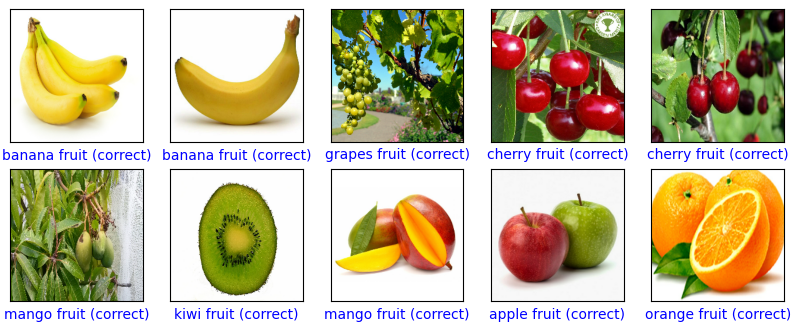

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in test_ds.take(1):
    preds = model.predict(images)

    y_pred = preds.argmax(axis=-1)
    y_true = labels.numpy()

    for i in range(10):
        plt.subplot(5, 5, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        plt.imshow(images[i].numpy().astype("uint8"))

        correct = y_pred[i] == y_true[i]
        color = "blue" if correct else "red"
        status = "correct" if correct else "incorrect"

        plt.xlabel(
            f"{class_names[y_pred[i]]} ({status})",
            color=color
        )

plt.show()

# **Enviando imagem**

In [ ]:
def load_and_prepare_image(img_path, img_size=(224, 224)):
    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    img = tf.keras.utils.img_to_array(img)
    img = tf.expand_dims(img, axis=0)
    return img

In [ ]:
model = tf.keras.models.load_model(
    "modelo_frutas_mobilenet.h5",
    custom_objects={"preprocess_input": preprocess_input}
)

In [ ]:
img = load_and_prepare_image("/content/images (2).jfif")

In [ ]:
model.evaluate(test_ds.take(1), verbose=0)

pred = model.predict(img)
pred_class = np.argmax(pred, axis=-1)[0]
confidence = np.max(pred)

print("Classe prevista:", class_names[pred_class])
print("Confiança:", f"{confidence * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Classe prevista: kiwi fruit
Confiança: 98.28%
